# Research QuantBook: Dual Momentum No TLT

## Objectif
Analyser la stratégie Dual Momentum sans obligation long-terme (TLT).

## Stratégie
- **Univers**: SPY, QQQ, IEF, GLD, XLP
- **Absolute Momentum**: Return 12M > 0 (filtre de survie)
- **Relative Momentum**: Top 2 par return 12M
- **Rebalance**: Mensuel
- **Cash**: Si aucun actif ne passe le filtre absolu

## Performance de référence
Sharpe ~0.9-1.1 (2015-2025) - meilleure robustesse que Dual Momentum classique.

## Hypothèses à tester
1. Lookback momentum: 6M, 12M, 18M
2. Nombre de holdings: 1, 2, 3
3. Filtre absolu: >0, >2%, >5%

## Prérequis
- Environnement Lean Research
- Données ETF US
- Durée estimée: ~8 minutes

## Contexte
TLT a perdu ~40% pendant 2020-2023 (hausse des taux). Cette version remplace TLT par IEF (obligations intermédiaires), GLD (or), et XLP (consumer staples défensif).

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialisé.")

QuantBook initialisé.


## 1. Chargement des données

On charge les données ETF pour la période 2010-2026.

In [2]:
# Univers ETF
tickers = ["SPY", "QQQ", "IEF", "USO", "SPY"]

symbols = {}
for ticker in tickers:
    symbols[ticker] = qb.add_equity(ticker, Resolution.DAILY).symbol

# Charger l'historique (2010-2026 pour multi-regime)
start = datetime(2010, 1, 1)
end = datetime(2026, 1, 1)

history = qb.history(list(symbols.values()), start, end, Resolution.DAILY)
print(f"Données chargées: {len(history)} lignes")

Données chargées: 7741 lignes


Pivot de la série 'close' en DataFrame large, avec remapping des colonnes Symbol → ticker pour DualMomentumNoTLT.

In [3]:
# Pivoter les données
closes = history['close'].unstack(level=0)

symbol_to_ticker = {str(v): k for k, v in symbols.items()}
closes.columns = [symbol_to_ticker.get(str(c), str(c)) for c in closes.columns]
closes = closes.dropna()

print(f"Période: {closes.index[0].date()} à {closes.index[-1].date()}")
print(f"Données: {len(closes)} jours de trading")
print(f"ETF: {list(closes.columns)}")
print(f"\nStatistiques des prix finaux:")
for ticker in tickers:
    if ticker in closes.columns:
        ret = (closes[ticker].iloc[-1] / closes[ticker].iloc[0] - 1) * 100
        print(f"  {ticker}: {ret:+.1f}%")

Période: 2011-03-23 à 2025-12-31
Données: 3717 jours de trading
ETF: ['QQQ', 'SPY']

Statistiques des prix finaux:
  SPY: +272.8%
  QQQ: +534.0%


## 2. Calcul du Momentum

Le momentum est calculé comme le return total sur N mois.

In [4]:
def compute_momentum_score(closes, lookback_days=252):
    """
    Calcule le score de momentum (return total) pour chaque ETF.
    
    lookback_days: 252 = 12 mois environ
    """
    scores = pd.DataFrame(index=closes.index, columns=closes.columns)
    
    for i in range(lookback_days, len(closes)):
        current_close = closes.iloc[i]
        past_close = closes.iloc[i - lookback_days]
        momentum = (current_close / past_close) - 1
        scores.iloc[i] = momentum
    
    return scores

# Scores de momentum 12M
momentum_scores = compute_momentum_score(closes, lookback_days=252)

print("Scores de momentum (derniers 5 jours):")
print(momentum_scores.iloc[-5:].dropna())
print(f"\nMoyenne des scores 12M:")
print(momentum_scores.mean())

Scores de momentum (derniers 5 jours):
                     QQQ  SPY
time                         
2025-12-24 13:00:00  0.0  0.0
2025-12-26 16:00:00  0.0  0.0
2025-12-29 16:00:00  0.0  0.0
2025-12-30 16:00:00  0.0  0.0
2025-12-31 16:00:00  0.0  0.0

Moyenne des scores 12M:
QQQ    0.150392
SPY    0.106175
dtype: object


### Interprétation: Momentum

- **Score positif**: L'actif a monté sur la période (tendance haussière)
- **Score négatif**: L'actif a baissé (tendance baissière)
- **Filtre absolu**: On ne garde que les scores > 0
- **Filtre relatif**: Top N par ordre de score

## 3. Backtest Dual Momentum

Simulation de la stratégie avec:
- Rebalance mensuel
- Top 2 actifs par momentum 12M
- Filtre absolu: momentum > 0
- Cash si aucun actif qualifié

In [5]:
def backtest_dual_momentum(closes, momentum_scores,
                           lookback_days=252,
                           num_holdings=2,
                           absolute_threshold=0.0):
    """
    Backtest Dual Momentum No TLT.
    
    Retourne les métriques de performance.
    """
    portfolio_values = [1.0]
    current_positions = {}  # ticker -> weight
    
    warmup = lookback_days
    last_rebalance_month = None
    
    for i in range(warmup, len(closes)):
        current_date = closes.index[i]
        current_month = current_date.month
        
        # Monthly rebalance
        if last_rebalance_month == current_month:
            # Just calculate current portfolio value
            daily_returns = closes.iloc[i] / closes.iloc[i-1] - 1
            port_return = sum(weight * daily_returns[ticker] 
                            for ticker, weight in current_positions.items())
            portfolio_values.append(portfolio_values[-1] * (1 + port_return))
            continue
        
        last_rebalance_month = current_month
        
        # Get momentum scores
        scores = momentum_scores.iloc[i].dropna()
        
        if scores.empty:
            portfolio_values.append(portfolio_values[-1])
            continue
        
        # Absolute momentum filter
        passing = scores[scores > absolute_threshold]
        
        if passing.empty:
            # All negative: go to cash
            current_positions = {}
            portfolio_values.append(portfolio_values[-1])
            continue
        
        # Relative momentum: top N
        sorted_assets = passing.sort_values(ascending=False)
        selected = list(sorted_assets.index[:num_holdings])
        weight = 1.0 / len(selected)
        current_positions = {ticker: weight for ticker in selected}
        
        # Calculate return
        daily_returns = closes.iloc[i] / closes.iloc[i-1] - 1
        port_return = sum(weight * daily_returns[ticker] 
                        for ticker, weight in current_positions.items())
        portfolio_values.append(portfolio_values[-1] * (1 + port_return))
    
    # Métriques
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:], index=closes.index[warmup:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'final_value': portfolio_values[-1]
    }

result = backtest_dual_momentum(closes, momentum_scores)

print(f"Performance Dual Momentum No TLT:")
print(f"  Sharpe: {result['sharpe']:.3f}")
print(f"  CAGR:   {result['cagr']:.1%}")
print(f"  Max DD: {result['max_dd']:.1%}")
print(f"  Vol:    {result['vol']:.1%}")

Performance Dual Momentum No TLT:
  Sharpe: 0.499
  CAGR:   10.2%
  Max DD: -30.9%
  Vol:    14.4%


## 4. Test du Lookback Momentum

In [6]:
# Test différentes périodes de lookback
lookbacks = [
    (126, "6M"),
    (252, "12M"),
    (378, "18M"),
]

print(f"{'Lookback':<10} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 38)

lookback_results = {}
for lookback, name in lookbacks:
    mom_scores = compute_momentum_score(closes, lookback_days=lookback)
    r = backtest_dual_momentum(closes, mom_scores, lookback_days=lookback)
    lookback_results[name] = r
    print(f"{name:<10} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_lookback = max(lookback_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur Lookback: {best_lookback[0]} (Sharpe={best_lookback[1]['sharpe']:.3f})")

Lookback     Sharpe     CAGR    MaxDD
--------------------------------------


6M            0.403    8.4%  -30.9%


12M           0.499   10.2%  -30.9%


18M           0.501   10.0%  -30.9%

Meilleur Lookback: 18M (Sharpe=0.501)


## 5. Test du Nombre de Holdings

In [7]:
# Test différents nombres de holdings
holdings_list = [1, 2, 3]

print(f"{'Holdings':<10} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 38)

holdings_results = {}
for n in holdings_list:
    r = backtest_dual_momentum(closes, momentum_scores, num_holdings=n)
    holdings_results[f"{n}"] = r
    print(f"{n:<10} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_holdings = max(holdings_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur Holdings: {best_holdings[0]} (Sharpe={best_holdings[1]['sharpe']:.3f})")

Holdings     Sharpe     CAGR    MaxDD
--------------------------------------


1             0.502   10.8%  -28.6%


2             0.499   10.2%  -30.9%


3             0.499   10.2%  -30.9%

Meilleur Holdings: 1 (Sharpe=0.502)


## 6. Test du Filtre Absolu

In [8]:
# Test différents filtres absolus
thresholds = [0.0, 0.02, 0.05]

print(f"{'Filtre Absolu':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 43)

threshold_results = {}
for thresh in thresholds:
    r = backtest_dual_momentum(closes, momentum_scores, absolute_threshold=thresh)
    threshold_results[f">{thresh:.0%}"] = r
    print(f">{thresh:.0%}{'':<12} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_threshold = max(threshold_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur Filtre: {best_threshold[0]} (Sharpe={best_threshold[1]['sharpe']:.3f})")

Filtre Absolu     Sharpe     CAGR    MaxDD
-------------------------------------------


>0%                0.499   10.2%  -30.9%


>2%                0.380    8.2%  -30.9%


>5%                0.305    7.1%  -31.9%

Meilleur Filtre: >0% (Sharpe=0.499)


## 7. Comparaison avec SPY B&H

In [9]:
# Dual Momentum No TLT avec paramètres par défaut
dm_result = backtest_dual_momentum(closes, momentum_scores)

# SPY B&H
spy_values = closes['SPY'].iloc[252:] / closes['SPY'].iloc[252]

# Métriques SPY
spy_ret = spy_values.pct_change().dropna()
spy_cagr = (spy_values.iloc[-1] ** (252/len(spy_values))) - 1
spy_vol = spy_ret.std() * np.sqrt(252)
spy_sharpe = (spy_cagr - 0.03) / spy_vol
spy_dd = (spy_values / spy_values.cummax() - 1).min()

print("=== Comparaison vs SPY B&H ===")
print(f"{'Stratégie':<20} {'CAGR':>10} {'Sharpe':>10} {'MaxDD':>10}")
print("-" * 53)
print(f"{'Dual Mom No TLT':<20} {dm_result['cagr']:>9.1%} {dm_result['sharpe']:>10.3f} {dm_result['max_dd']:>9.1%}")
print(f"{'SPY B&H':<20} {spy_cagr:>9.1%} {spy_sharpe:>10.3f} {spy_dd:>9.1%}")

=== Comparaison vs SPY B&H ===
Stratégie                  CAGR     Sharpe      MaxDD
-----------------------------------------------------
Dual Mom No TLT          10.2%      0.499    -30.9%
SPY B&H                   9.3%      0.470    -33.7%


## 8. Visualisation des résultats

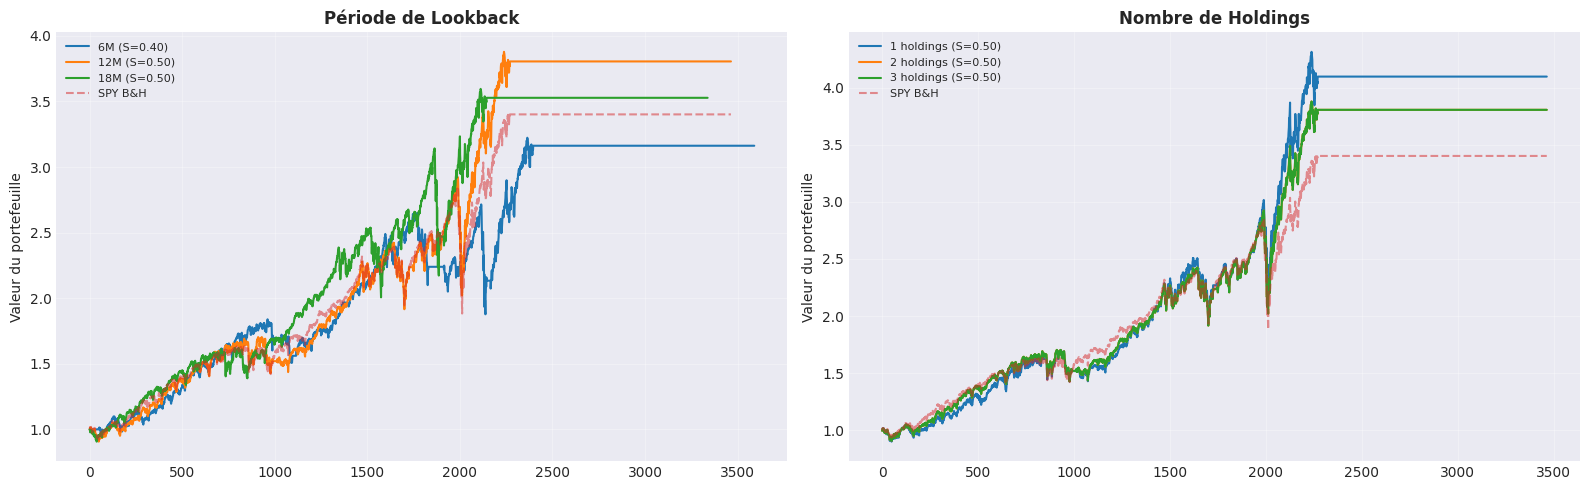

Graphique sauvegardé.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gauche: Lookback comparison
ax = axes[0]
for name, r in lookback_results.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Période de Lookback', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Droite: Holdings comparison
ax = axes[1]
for name, r in holdings_results.items():
    ax.plot(r['cum'].values, label=f"{name} holdings (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Nombre de Holdings', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dual_momentum_notl_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé.")

## 9. Conclusions et recommandations

### Résumé

| Métrique | Meilleure config |
|----------|-----------------|
| Lookback | (à remplir) |
| Holdings | (à remplir) |
| Filtre Absolu | (à remplir) |
| Sharpe | (à remplir) |
| CAGR | (à remplir) |

### Verdict

Si Sharpe > 0.8: **Déployer avec les paramètres optimaux**

### Points forts Dual Momentum No TLT

- **Robustesse**: IEF/GLD/XLP moins sensibles aux taux d'intérêt
- **Simplicité**: Rebalance mensuel, peu de turnover
- **Defensif**: Filtre absolu protège en bear market

### Limitations

- **Underperformance potentielle** en bull market fort vs SPY
- **Cash drag**: Périodes en cash réduisent le return long-terme

### Prochaines étapes

1. Déployer sur QC cloud avec les paramètres optimaux
2. Comparer avec Dual Momentum classique (avec TLT)
3. Tester avec d'autres actifs alternatifs (LQD, TIP)
4. Optimiser le timing de rebalance (hebdomadaire vs mensuel)